# Исследовательский анализ торговой стратегии

В анализ включены 130 сделок, соответствующих актуальным правилам торгового алгоритма.

## Цели анализа

1. Оценить общую результативность и устойчивость торговой стратегии.
2. Изучить распределение основных торговых признаков.
3. Проверить заранее сформулированные гипотезы.
4. Провести дополнительный исследовательский анализ и выявить потенциальные закономерности для дальнейшей проверки.

## Предварительно сформулированные гипотезы

**H1. Влияние рыночной фазы BTC.**  
Сделки в благоприятных фазах BTC (`calm_flat`, `calm_decline`) должны показывать более высокую результативность, чем сделки в остальных фазах.

**H2. Эффективность повторного входа.**  
Повторные открытия сделок после получения убытка не показывают значительно худших результатов по сравнению с первичными входами.

**H3. Выход при появлении сильного покупателя.**  
Досрочное закрытие позиции при появлении заранее определённых признаков силы покупателя может улучшать результат управления позицией.

Гипотезы были сформулированы до анализа итоговых результатов. Остальные обнаруженные зависимости рассматриваются как исследовательские и требуют последующей проверки на новых данных.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fact_trades = pd.read_excel ('../data/fact_trades_clean.xlsx')

## 1. Общие показатели стратегии

Сначала оценим результаты стратегии на всей выборке без разделения сделок
по отдельным торговым факторам. 

Рассчитаем профит-фактор, математическое ожидание сделки, долю положительных сделок,
среднюю прибыль и убыток, суммарный результат и максимальную серию убыточных сделок.

In [2]:
gross_profit = fact_trades.loc[fact_trades['result_r'] > 0, 'result_r'].sum()
gross_loss = fact_trades.loc[fact_trades['result_r'] < 0, 'result_r'].sum()
profit_factor = gross_profit / abs(gross_loss)
win_rate = (fact_trades['result_r'] > 0).mean()
expectancy = fact_trades['result_r'].mean()
average_win = fact_trades.loc[fact_trades['result_r'] > 0, 'result_r'].mean()
average_loss = fact_trades.loc[fact_trades['result_r'] < 0, 'result_r'].mean()
net_r = fact_trades['result_r'].sum()

def max_losing_streak(results):
    max_streak = 0
    current_streak = 0
    for result in results:
        if result < 0:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0
    return max_streak
max_lose_streak = max_losing_streak(fact_trades['result_r'])

print(f'Количество сделок: {len(fact_trades)}\n'
    f'Profit Factor: {profit_factor:.2f}\n'
    f'Win Rate: {win_rate:.1%}\n'
    f'Ожидаемая прибыль со сделки: {expectancy:.2f}R\n'
    f'Средняя прибыльная сделка: {average_win:.1f}R\n'
    f'Средняя убыточная сделка: {average_loss:.2f}R\n'
    f'Суммарная прибыль: {net_r:.1f}R\n'
    f'Максимальная убыточная серия: {max_lose_streak} сделок')

Количество сделок: 130
Profit Factor: 1.58
Win Rate: 30.8%
Ожидаемая прибыль со сделки: 0.43R
Средняя прибыльная сделка: 3.8R
Средняя убыточная сделка: -1.07R
Суммарная прибыль: 55.8R
Максимальная убыточная серия: 6 сделок


### Вывод по общим показателям стратегии
В результате расчёта общих показателей стратегии на основе 130 сделок был получен профит-фактор 1.58 при ожидаемой прибыли 0,43R на сделку. 
Низкая доля прибыльных сделок 30.8% объясняется высокой средней прибылью на сделку - 3.8R при среднем убытке 1,07R.
Фактическая статистика сходится с установленными правилами риск-менеджмента. Расчетный риск на сделку должен быть равен 1R, а прибыль находиться в диапазоне 3-5R.
Суммарная прибыль составила 55.8R. Максимальная убыточная серия включала 6 сделок.
Максимальная серия снизилась с 15 сделок в предыдущей версии алгоритма до 6 в текущей выборке. Это согласуется с целью внесённых изменений, 
однако напрямую приписать снижение изменениям алгоритма нельзя из-за различий между периодами наблюдения.

## 2. Динамика результатов

Рассмотрим изменение накопленного результата стратегии во времени.
Это позволяет оценить устойчивость результата и наличие продолжительных
периодов роста, стагнации или просадки.

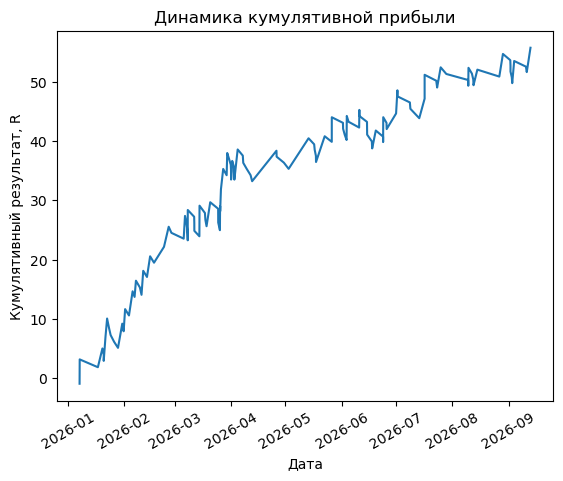

In [3]:
fact_trades['cumulative_r'] = fact_trades['result_r'].cumsum()

sns.lineplot(
    data=fact_trades,
    x='open_datetime',
    y='cumulative_r')

plt.title('Динамика кумулятивной прибыли')
plt.xlabel('Дата')
plt.ylabel('Кумулятивный результат, R')
plt.xticks(rotation=30)
plt.show()

### Вывод по динамике результатов
График динамики кумулятивной прибыли показывает уверенный рост прибыли в течение всего периода.
С начала апреля заметно незначительное снижение темпов роста.
Относительно короткая максимальная убыточная серия согласуется с визуально достаточно устойчивой кривой капитала.

## 3. Одномерный анализ

На данном этапе рассмотрим распределения отдельных признаков без их
взаимосвязи с другими переменными.

### 3.1. Распределение результатов сделок

Рассмотрим распределение финансового результата отдельных сделок,
нормализованного в единицах риска R.

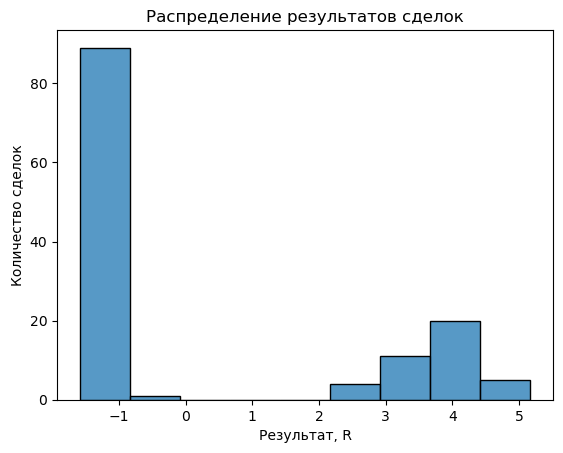

In [4]:
sns.histplot(data=fact_trades, x='result_r')
plt.title('Распределение результатов сделок')
plt.xlabel('Результат, R')
plt.ylabel('Количество сделок')
plt.show()

### 3.2. Распределение сделок по времени входа

Распределение количества входов по часам используется для оценки
фактической торговой активности в течение суток и последующего выбора
разумных временных интервалов для сравнительного анализа.

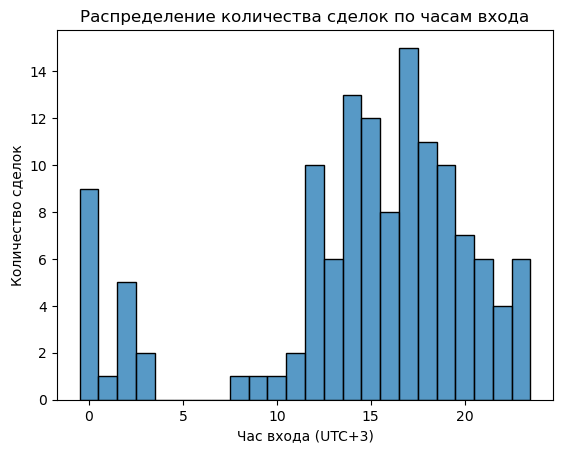

In [5]:
sns.histplot(data=fact_trades, x='open_hour', discrete=True)
plt.title('Распределение количества сделок по часам входа')
plt.xlabel('Час входа (UTC+3)')
plt.ylabel('Количество сделок')
plt.show()

### 3.3. Распределение максимального благоприятного движения

`max_move_r` показывает максимальное благоприятное движение цены после
входа, выраженное в единицах риска R.

Метрика будет использоваться далее для анализа потенциала сделок и
эффективности текущего управления позицией.

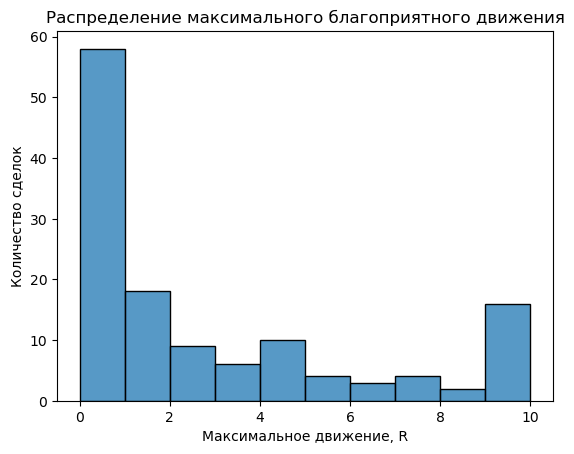

In [6]:
sns.histplot(data=fact_trades, x='max_move_r', bins = list (range (0,11)))
plt.title('Распределение максимального благоприятного движения')
plt.xlabel('Максимальное движение, R')
plt.ylabel('Количество сделок')
plt.show()

### 3.4 Распределение размера spike

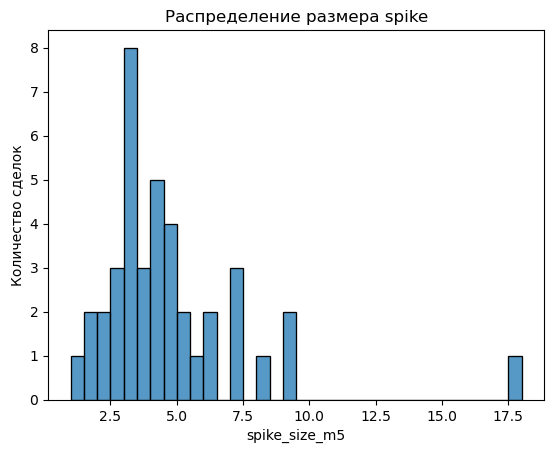

In [7]:
sns.histplot(data=fact_trades, x='spike_size_m5', bins = list (range (0,18)), binwidth = 0.5)
plt.title('Распределение размера spike')
plt.ylabel('Количество сделок')
plt.show()

### 3.5 Распределение глубины первичного пробоя

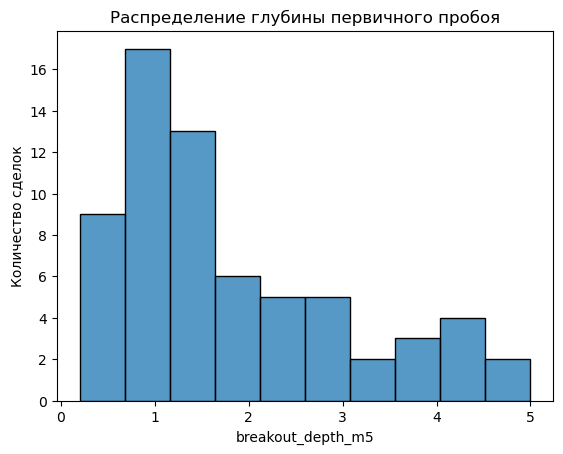

In [8]:
sns.histplot(data=fact_trades, x='breakout_depth_m5', bins = list (range (0,10)), binwidth = 0.5)
plt.title('Распределение глубины первичного пробоя')
plt.ylabel('Количество сделок')
plt.show()

### 3.6 Распределение глубины отката

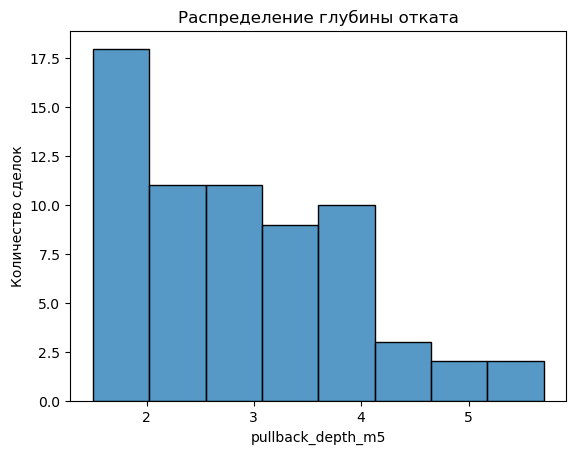

In [9]:
sns.histplot(data=fact_trades, x='pullback_depth_m5')
plt.title('Распределение глубины отката')
plt.ylabel('Количество сделок')
plt.show()

### 3.7 Распределение отношения величины отката к первичному пробою

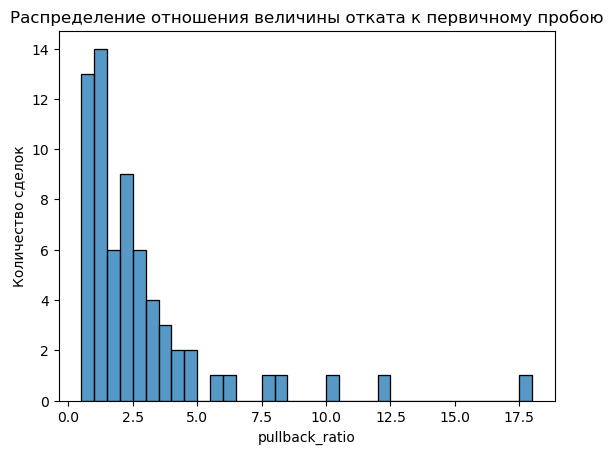

In [10]:
sns.histplot(data=fact_trades, x='pullback_ratio', bins = list (range (0,19)), binwidth = 0.5)
plt.title('Распределение отношения величины отката к первичному пробою')
plt.ylabel('Количество сделок')
plt.show()

### Выводы по одномерному анализу
1. Распределение количества сделок по часам входа показывает отсутствие входов в период с 4:00 до 8:00. Значимых кластеров для сегментации признака по этому графику более не наблюдается.
2. Из распределения максимального благоприятного движения заметно значительное снижение количества сделок после отметки в 5R. Можно сделать вывод об отсутствии оснований для увеличения фиксируемого тейк-профита выше 5R.
Также значительная часть сделок имело потенциал хода до 10R и более. Следовательно, имеет смысл продолжить исследования методов удержания позиций или частичного выхода.
3. Распределение spike_size_m5 имеет выраженную концентрацию наблюдений примерно в диапазоне 3–5 и длинный правый хвост. Явственной естественной границы для разделения признака на категории не наблюдается.
4. Большинство наблюдений pullback_ratio сосредоточено ниже 4, после чего частота резко снижается и формируется длинный правый хвост. 

## 4. Сравнительный анализ

Для категориальных признаков сравним результативность отдельных групп
сделок.

Для каждой группы рассчитываются:
- количество сделок;
- математическое ожидание одной сделки;
- суммарный результат в R;
- профит-фактор;
- доля прибыльных сделок.

Основными показателями качества группы являются математическое ожидание
и профит-фактор. Количество сделок используется для оценки объёма выборки,
а доля прибыльных сделок — как дополнительная характеристика структуры результата.

In [11]:
def compare_groups(df, group_col):
    results = []
    for group_name, group in df.groupby(group_col):
        n_trades = len(group)
        net_r = group['result_r'].sum().round(1)
        expectancy_r = group['result_r'].mean()
        win_rate = (group['result_r'] > 0).mean()
        gross_profit = group.loc[group['result_r'] > 0, 'result_r'].sum()
        gross_loss = group.loc[group['result_r'] < 0, 'result_r'].sum()
        profit_factor = gross_profit / abs(gross_loss)
        results.append({'group': group_name,
            'n_trades': n_trades,
            'expectancy_r': expectancy_r,
            'net_r': net_r,
            'profit_factor': profit_factor,
            'win_rate_%': win_rate * 100})
    result_df = pd.DataFrame(results)
    result_df['net_r'] = result_df['net_r'].round(2)
    result_df['expectancy_r'] = result_df['expectancy_r'].round(2)
    result_df['profit_factor'] = result_df['profit_factor'].round(2)
    result_df['win_rate_%'] = result_df['win_rate_%'].round(1)
    result_df = result_df.rename(columns={'group': group_col})
    return result_df

### 4.1. Проверка предварительных гипотез

#### 4.1.1. Рыночная фаза.

В соответствии с правилами стратегии фазы BTC были разделены на две группы:

**Благоприятные:**
- `calm_flat`;
- `calm_decline`.

**Неблагоприятные:**
- остальные четыре типа рыночной фазы.

Проверим, соответствует ли фактическая результативность стратегии
предварительно определённому фильтру рыночной фазы.

In [12]:
fact_trades['phase_group'] = (fact_trades['btc_phase'].isin(['calm_flat', 'calm_decline']).map({True: 'favorable',False: 'unfavorable'}))
btc_phase_stats = compare_groups(fact_trades,'phase_group')
btc_phase_stats

,phase_group,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,favorable,86,0.54,46.9,1.78,32.6
1,unfavorable,44,0.20,8.9,1.25,27.3


Торговые показатели группы favorable превосходят unfavorable: профит-фактор 1.78 против 1.25, мат.ожидание 0.54 против 0.20.
Рассмотрим результаты отдельно для каждой фазы

In [13]:
phase_stats = compare_groups(fact_trades,'btc_phase')
phase_stats.sort_values ('n_trades', ascending = False)

,btc_phase,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,calm_decline,49,0.81,39.5,2.26,38.8
1,calm_flat,37,0.20,7.4,1.26,24.3
3,choppy_flat,27,-0.12,-3.2,0.87,18.5
5,uncertain_growth,7,1.38,9.7,4.11,57.1
2,choppy_decline,6,0.33,2.0,1.41,33.3
4,dominant_growth,4,0.11,0.4,1.13,25.0


#### 4.1.2. Первоначальные и повторные входы.

В анализ включены только повторные входы, соответствующие актуальным правилам
стратегии. Ошибочные и не соответствующие текущему алгоритму повторные
входы были исключены на этапе предобработки данных.

Сравним качество валидных повторных входов с первоначальными входами.

In [14]:
fact_trades['entry_attempt'] = fact_trades['re_entry'].map({False: 'initial',True: 're-entry'})
reentry_stats = compare_groups(fact_trades,'entry_attempt')
reentry_stats

,entry_attempt,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,initial,112,0.43,48.4,1.59,31.2
1,re-entry,18,0.41,7.4,1.52,27.8


#### 4.1.3. Выход при появлении сильного покупателя.

Для сделок, при ведении которых по установленным признакам появился сильный покупатель, будет рассмотрено два сценария. В первом сценарии никаких дополнительных действий не предпринимается, заявки стоп-лосс и тейк-профит остаются на своих местах. Во втором сценарии сделка при появлении надежного признака сразу же закрывается вручную. Итоговый результат для выводов - разница между суммарным доходом второго и первого сценариев.

In [15]:
# Оставляем только сделки, в которых был зафиксирован сильный покупатель
buyer_trades = fact_trades[fact_trades['r_at_buyer_appearance'].notna()].copy()

# Для каждой сделки рассчитываем изменение результата при гипотетическом выходе в момент появления покупателя
buyer_trades['difference_r'] = (buyer_trades['r_at_buyer_appearance']- buyer_trades['result_r'])
buyer_trades = buyer_trades[['ticker','open_datetime','result_r','r_at_buyer_appearance','difference_r']]
print (f'{buyer_trades}\n\nСуммарная разность в рисках: {buyer_trades ['difference_r'].sum()}')

        ticker       open_datetime  result_r  r_at_buyer_appearance  \
4      STOUSDT 2026-01-20 19:26:25     -1.05                    1.5   
18    BIRBUSDT 2026-02-07 13:38:16      2.74                    1.5   
42   POLYXUSDT 2026-03-18 11:41:42     -1.06                    1.0   
74    BILLUSDT 2026-05-17 02:20:22     -0.93                    0.0   
114    ACEUSDT 2026-08-09 20:27:00      3.03                    0.0   
120    BMTUSDT 2026-08-28 20:11:36      3.82                    0.0   
126    HNTUSDT 2026-09-04 00:54:13      3.74                    2.8   

     difference_r  
4            2.55  
18          -1.24  
42           2.06  
74           0.93  
114         -3.03  
120         -3.82  
126         -0.94  

Суммарная разность в рисках: -3.49


#### Выводы по проверке предварительных гипотез
1. Favorable фазы имеют мат. ожидание (E) 0.54R против 0.20R у unfavorable. Однако декомпозиция показала существенную неоднородность внутри агрегированных групп. Основной положительный результат favorable group связан с calm_decline (N=49, E=0.81R, PF=2.26), тогда как calm_flat показывает значительно более слабые результаты (N=37, E=0.20R, PF=1.26). Среди достаточно представленных неблагоприятных фаз choppy_flat имеет отрицательное expectancy −0.12R (N=27). Остальные фазы имеют N<10 и интерпретируются только описательно.
2. Сделки, представляющие из себя повторные входы, имели профит-фактор 1.52 и мат. ожидание 0.41R против 1.59 и 0.43R соответственно для сделок с первичным входом. Результат почти идентичен и говорит об отсутствии оснований для запрета второй попытки. Рекомендуется проанализировать возможность роста общего числа сделок за счет увеличения числа повторных входов. 
3. В текущей выборке выход при появлении сильного покупателя ухудшил бы суммарный результат на 3.49R. Полученные данные не дают оснований добавлять обязательный досрочный выход по этому признаку.

Необходимо учесть величину выборок для гипотез 2 и 3. Количество повторных входов составило всего 18 случаев, а выборка для анализа сценариев при появлении сильного покупателя - всего 7. Такие выборки относительно малы для уверенных выводов. Это говорит о необходимости продолжить собирать статистику по этим признакам для дальнейшего анализа.

### 4.2. Поиск закономерностей в категориальных признаках

#### 4.2.1. Возможности повторных входов

Промежуточные результаты проверки гипотезы об эффективности повторных входов говорят о возможности развитии системы за счет увеличения количества повторных входов. Рассмотрим количество возможностей повторных входов, сравним его с количеством убыточных первичных и фактических повторных входов. Сравним количество возможных повторных входов типов spike и structure.

In [16]:
total_opportunities = fact_trades['reentry_opportunity'].notna().sum()
actual_reentries_rate = fact_trades['re_entry'].sum() / total_opportunities
initial_loss_trades = len(fact_trades[(fact_trades['re_entry'] == False) & (fact_trades['result_r'] < 0)])
opportunity_rate = total_opportunities / initial_loss_trades
opportunity_structure = len (fact_trades[fact_trades['reentry_opportunity'] == 'structure'])
opportunity_spike = len (fact_trades[fact_trades['reentry_opportunity'] == 'spike'])

print(f' Количество убыточных первичных входов: {initial_loss_trades}\n',
    f'Количество возможностей повторного входа: {total_opportunities}\n',
    f'Доля возможностей повторного входа после убыточных первичных входов: {opportunity_rate:.1%}\n',
    f'Доля совершенных повторных входов среди возможных: {actual_reentries_rate:.1%}\n',
    f'Количество structure среди возможностей повторного входа: {opportunity_structure}\n',
    f'Количество spike среди возможностей повторного входа: {opportunity_spike}\n')

 Количество убыточных первичных входов: 77
 Количество возможностей повторного входа: 35
 Доля возможностей повторного входа после убыточных первичных входов: 45.5%
 Доля совершенных повторных входов среди возможных: 51.4%
 Количество structure среди возможностей повторного входа: 19
 Количество spike среди возможностей повторного входа: 16



#### 4.2.2. Будни и выходные

Проверим, различается ли результативность стратегии в будние и выходные
дни.

In [17]:
weekend_stats = compare_groups(fact_trades,'day_type')
weekend_stats

,day_type,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,weekday,96,0.31,30.1,1.41,29.2
1,weekend,34,0.76,25.7,2.11,35.3


Показатели значительно отличаются. Проверим, не объясняется ли это распределением рыночных фаз по дням недели

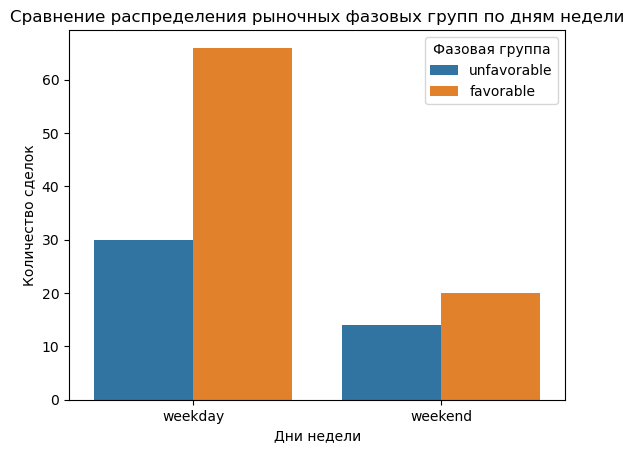

In [18]:
sns.countplot (data = fact_trades, x = 'day_type', hue = 'phase_group')
plt.title ('Сравнение распределения рыночных фазовых групп по дням недели')
plt.legend (title = 'Фазовая группа')
plt.ylabel ('Количество сделок')
plt.xlabel ('Дни недели')
plt.show()

#### 4.2.3. Типы входов structure и spike

Сравним результативность двух основных типов торгового входа.

In [19]:
entry_type_stats = compare_groups(fact_trades,'entry_type')
entry_type_stats

,entry_type,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,spike,40,0.81,32.5,2.22,37.5
1,structure,90,0.26,23.3,1.34,27.8


#### 4.2.4. Instant и stepped spike

Отдельно сравним два типа spike-входов: мгновенный `instant` и развивающийся
в несколько шагов `stepped`.

In [20]:
spike_stats = compare_groups(fact_trades,'spike_type')
spike_stats

,spike_type,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,instant,19,0.28,5.3,1.36,26.3
1,stepped,20,1.41,28.2,3.60,50.0


#### 4.2.5. Вход в spike выше и ниже уровня

In [21]:
entry_vs_level_stats = compare_groups(fact_trades,'entry_vs_level')
entry_vs_level_stats

,entry_vs_level,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,above,23,1.37,31.5,3.41,47.8
1,below,16,0.12,2.0,1.16,25.0


Значительная разница в результатах сильно схожа с результатами сравнения instant и stepped spike. Необходимо проверить, не объясняются ли похожие результаты схожестью выборок в группах.

In [22]:
spike_avg = fact_trades.copy()
spike_avg = spike_avg [spike_avg ['spike_type'].notna()].groupby ('spike_type')['entry_vs_level'].value_counts()
print (spike_avg)

spike_type  entry_vs_level
instant     above             12
            below              7
stepped     above             11
            below              9
Name: count, dtype: int64


#### 4.2.6. Вход в structure вблизи и вдали от уровня


In [23]:
fact_trades ['far_entry'] = fact_trades ['far_entry'].astype ('boolean')
far_entry_map = fact_trades [fact_trades ['entry_type'] == 'structure'].copy()
far_entry_map['far_entry'] = far_entry_map['far_entry'].map({True: 'far_entry', False: 'close_entry'})
far_entry_stats = compare_groups(far_entry_map,'far_entry')
far_entry_stats

,far_entry,n_trades,expectancy_r,net_r,profit_factor,win_rate_%
0,close_entry,72,0.31,22.5,1.41,29.2
1,far_entry,18,0.04,0.7,1.05,22.2


#### Выводы по поиску закономерностей в категориальных признаках

1. Анализ показал, что в выборке повторный вход был возможен среди 45.5% убыточных первичных входов. При этом из 35 зафиксированных возможностей фактически было реализовано 18 (51.4%). Это говорит о хорошем потенциале роста количества сделок. Тем не менее, необходимо учитывать важные поправки. Потенциальное увеличение частоты ограничивается доступностью трейдера и дневным лимитом риска. Кроме того, более активное использование повторных входов не должно сопровождаться снижением требований к качеству сделок за счет повышенной эмоциональности трейдера.
2. Результаты торговли в выходные дни значительно лучше, чем в будни. Профит-фактор в выходные 2.11 против 1.41 в будни. Мат. ожидание 0.76R против 0.31R соответственно. Результаты проверки возможного влияния рыночной фазы на эти значения показали, что в выходные дни доля неблагоприятных фаз оказалась даже больше, чем в будни. Возможное объяснение для дальнейшего исследования — различия в рыночной активности и волатильности между буднями и выходными.
3. При открытии сделки с формацией входа spike профит-фактор составил 2.22 против 1.34 у формации structure. Мат.ожидание составило 0.81R против 0.26R соответственно. Следует учитывать, что количество сформировавшихся входов вида spike было всего 40 против 90 формации structure. Spike встречался заметно реже, но даже при этом принёс больше прибыли в совокупности: 32.5R против 23.3R у structure. Полученный результат делает характеристики spike-входов одним из приоритетных направлений дальнейшего анализа.
4. По результатам анализа видов формации spike было получено, что вход при stepped spike имеет значительно лучшие торговые показатели относительно instant spike. Профит-фактор 3.6 у stepped против 1.36 у instant. Мат. ожидание 1.41R против 0.28R.
При этом важно учесть, что в группах было 20 и 19 наблюдений, что относительно мало и требует дальнейшего расширения выборки.
5. Вход в spike выше уровня показал значительно лучшие результаты в отличие от входа под уровнем. Профит фактор 3.41 против 1.16, мат.ожидание 1.37R против 0.12R. Разница в показателях очень похожа на разницу в видах формаций spike. В результате сравнительного анализа было выявлено, что составы групп разнообразны. Значит значительная разница в показателях одной группы не объясняется разницей в другой. Таким образом, выявленная закономерность в разнице входа формации spike относительно уровня имеет место быть и требует дальнейшего накопления наблюдений.
6. Вход в structure вдали от уровня показал результаты хуже, чем вход вблизи. Профит-фактор 1.05 при входе вдали против 1.41 при входе вблизи. Мат. ожидание 0.04R против 0.31R соответственно. Таким образом, в текущей выборке не обнаружено преимуществ far entry, наблюдаемые показатели, напротив, ниже. Необходимо так же продолжить сбор наблюдений для более объективного сравнения.

### 4.3 Поиск закономерностей в числовых признаках

Для первичной оценки связи числовых признаков с результатом сделки сравним их распределения в прибыльных и убыточных сделках. Для каждой группы рассчитаем количество наблюдений, среднее и медианное значение. Учитывая правостороннюю асимметрию распределений, при интерпретации особое внимание будет уделено медиане.

In [24]:
fact_trades ['result_group'] = fact_trades ['result_r'].apply (lambda x: 'profit' if x > 0 else 'loss')

#### 4.3.1 Размер spike

In [25]:
fact_trades.groupby('result_group')['spike_size_m5'].agg(['count', 'mean', 'median']).reset_index()

,result_group,count,mean,median
0,loss,25,4.320000,4.1
1,profit,15,5.253333,4.1


#### 4.3.2 Глубина первичного пробоя

In [26]:
fact_trades.groupby('result_group')['breakout_depth_m5'].agg(['count', 'mean', 'median']).reset_index()

,result_group,count,mean,median
0,loss,47,1.900000,1.5
1,profit,19,1.526316,1.3


#### 4.3.3 Глубина отката

In [27]:
fact_trades.groupby('result_group')['pullback_depth_m5'].agg(['count', 'mean', 'median']).reset_index()

,result_group,count,mean,median
0,loss,47,2.821277,2.7
1,profit,19,2.989474,2.8


#### 4.3.4 Отношение отката к первичному пробою

In [28]:
fact_trades.groupby('result_group')['pullback_ratio'].agg(['count', 'mean', 'median']).reset_index()

,result_group,count,mean,median
0,loss,47,2.631915,1.6
1,profit,19,3.173684,2.2


#### Выводы по поиску закономерностей в числовых признаках

В рамках первичного сравнительного анализа выраженных различий между прибыльными и убыточными сделками по рассматриваемым числовым признакам не выявлено. Медианные значения размера spike и глубины отката практически совпадают. Для глубины первичного пробоя и отношения отката к пробою наблюдаются некоторые различия, однако они недостаточно выражены, чтобы на этапе EDA рассматривать эти признаки как потенциальные фильтры торговой системы.

### 5. Комплексный анализ

#### 5.1. Рыночная фаза и день недели

In [29]:
phase_day_stats = fact_trades.groupby (['phase_group', 'day_type']).agg (n_trades = ('ticker', 'count'), expectancy_r = ('result_r', 'mean')).copy().reset_index()
phase_day_stats ['expectancy_r']= phase_day_stats['expectancy_r'].round (2)
phase_day_stats

,phase_group,day_type,n_trades,expectancy_r
0,favorable,weekday,66,0.55
1,favorable,weekend,20,0.52
2,unfavorable,weekday,30,-0.21
3,unfavorable,weekend,14,1.10


#### 5.2. Рыночная фаза и тип входа

In [30]:
phase_entry_stats = fact_trades.groupby (['phase_group', 'entry_type']).agg (n_trades = ('ticker', 'count'), expectancy_r = ('result_r', 'mean')).copy().reset_index()
phase_entry_stats ['expectancy_r']= phase_entry_stats['expectancy_r'].round (2)
phase_entry_stats

,phase_group,entry_type,n_trades,expectancy_r
0,favorable,spike,25,0.93
1,favorable,structure,61,0.39
2,unfavorable,spike,15,0.62
3,unfavorable,structure,29,-0.02


### Выводы по комплексному анализу

1. В favorable фазах результаты практически не различаются между буднями и выходными: мат. ожидание E = 0.55R и 0.52R соответственно. Наблюдаемое в EDA преимущество выходных формируется преимущественно в unfavorable фазах: E = 1.10R в выходные против −0.21R в будни. Однако группа unfavorable × weekend содержит всего 14 наблюдений, поэтому этот результат следует рассматривать как предварительный и требующий дальнейшего накопления данных.
2. В обоих типах входа favorable фазы имеют более высокое наблюдаемое expectancy: 0.93R против 0.62R для spike и 0.39R против −0.02R для structure. Таким образом, преимущество favorable фаз наблюдается внутри обоих типов входа и не объясняется только различиями в соотношении spike и structure между фазами. При этом величина различий неодинакова, а группа unfavorable × spike содержит только 15 наблюдений, поэтому устойчивость эффекта требует дальнейшей статистической проверки.

## Конечные выводы по исследовательскому анализу

| Признак | Результат EDA | Статус |
|---|---|---|
| BTC phase | Favorable: E=0.54R; unfavorable: E=0.20R. Декомпозиция: calm_decline N=49, E=0.81R; calm_flat N=37, E=0.20R; choppy_flat N=27, E=−0.12R | Проверить устойчивость эффекта статистически, calm_decline — кандидат для отдельной проверки
| Re-entry | E = 0.41R у вторичных входов; 0.43R у первичных | Проверить отсутствие эффекта статистически |
| Buyer appearance | Досрочный выход: −3.49R относительно бездействия| Недостаточно данных для статистического анализа (N=7) |
| Re-entry opportunities | Реализована только часть доступных возможностей	| Оценка потенциала за рамками текущего анализа |
| Day type	| Weekend: E=0.76R; weekday: E=0.31R. После декомпозиции различие практически отсутствует в favorable, но велико в unfavorable при N=14 weekend | Эффект выходных интерпретировать осторожно; требуется больше данных|
| Entry type	| Spike: E = 0.81R; structure: E = 0.26R	| Проверить устойчивость эффекта статистически |
| Spike type	| Stepped: E = 1.41R; instant: E = 0.28R, но N~20	на группу | Проверить неопределённость статистически|
| Entry vs level	| Above: E = 1.37R; below: E = 0.12R, но N~20	на группу	| Проверить неопределённость статистически|
| Far entry	| Преимущества не обнаружено | Не использовать как дополнительный фильтр |
| Max move | Высокая доля движений более 10R | Изучение продолжается за рамками текущего анализа |
| Open hour | Нет видимых кластеров для сегментации | Не использовать как дополнительный фильтр |
| Прочие числовые признаки	| Выраженных различий winners/losses не обнаружено	| Не использовать как дополнительный фильтр |

По итогам EDA наиболее интересными направлениями для дальнейшей проверки являются влияние рыночной фазы BTC, эффективность повторных входов, различия между spike и structure, типами spike, а также положением входа относительно уровня для spike. Обнаруженные зависимости пока рассматриваются как предварительные: следующим этапом будет оценка их статистической устойчивости и неопределённости. Результаты с малым количеством наблюдений интерпретируются описательно и требуют дальнейшего накопления данных.

In [31]:
fact_trades.to_excel('../data/fact_trades_eda.xlsx', index=False)